In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm

import xesmf as xe

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/share/proj failed


In [5]:
months = range(1,13)
file_path = Path('/g/data/er8/users/cd3022/solar_drought/himawari_irradiance_means/')

month_darrays = {}

for m in months:
    month_str = f'{m:02d}'
    file = file_path / f'{month_str}_month_mean.nc'
    da_month = xr.open_dataarray(file)

    month_darrays[month_str] = da_month

# Combine into one dataset, with each region as a variable
himawari = xr.Dataset(month_darrays)
himawari = himawari.load()

In [6]:
months = range(1,13)
file_path = Path('/g/data/er8/users/cd3022/solar_drought/era5_irradiance_means')

month_darrays = {}

for m in months:
    month_str = f'{m:02d}'
    file = file_path / f'{month_str}_month_mean.nc'
    da_month = xr.open_dataarray(file)

    month_darrays[month_str] = da_month

# Combine into one dataset, with each region as a variable
era5 = xr.Dataset(month_darrays)
era5 = era5.load()

In [7]:
month_dict = {
        '01':'jan',
        '02':'feb',
        '03':'mar',
        '04':'apr',
        '05':'may',
        '06':'jun',
        '07':'jul',
        '08':'aug',
        '09':'sep',
        '10':'oct',
        '11':'nov',
        '12':'dec'
    }
himawari = himawari.rename(month_dict)
era5 = era5.rename(month_dict)

In [8]:
lon_max = himawari.longitude.max()
lon_min = himawari.longitude.min()
lat_max = himawari.latitude.max()
lat_min = himawari.latitude.min()

era5_aus = era5.sel(
    latitude=slice(lat_max, lat_min),
    longitude=slice(lon_min, lon_max)
)

# Absolute Difference

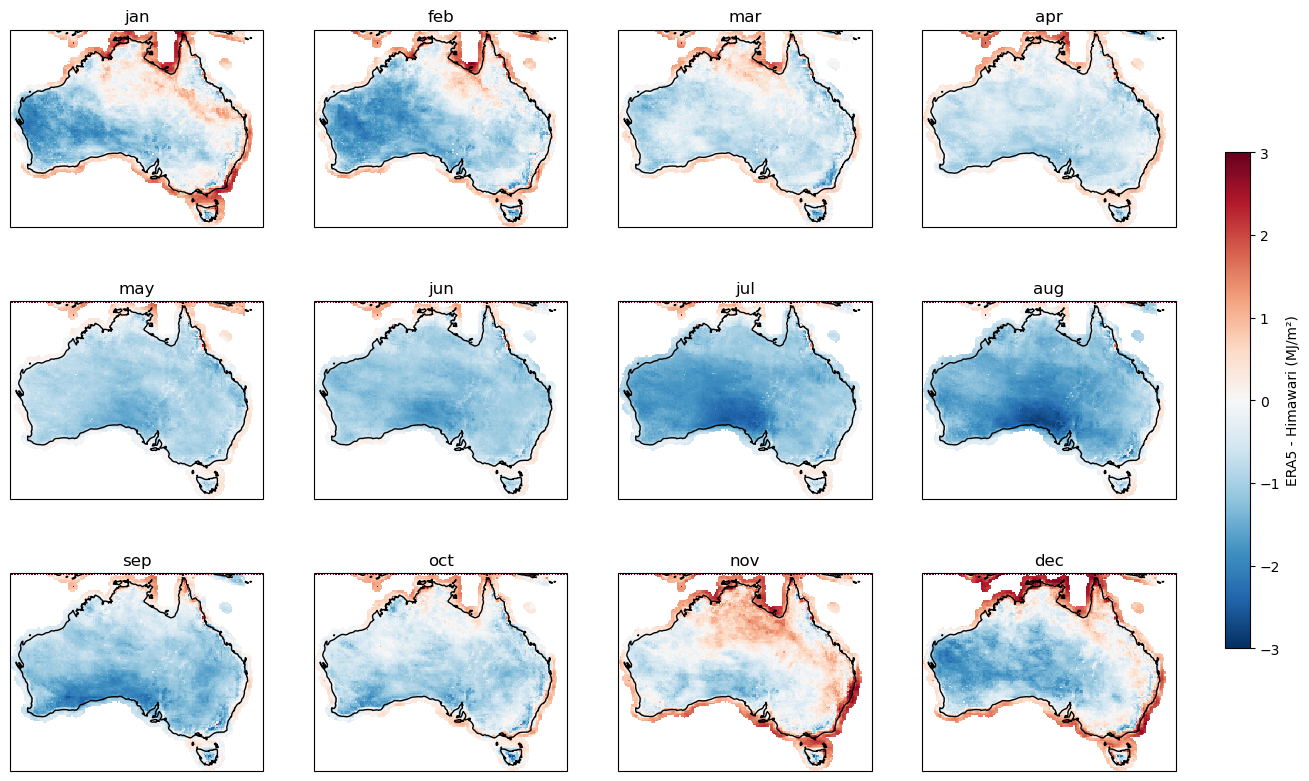

In [12]:
fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(16,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.flatten()
for i, month in enumerate(himawari.data_vars):
    him_data = himawari[month]
    era5_data = era5_aus[month]

    # regrid himawari to era5 resolution
    regridder = xe.Regridder(him_data, era5_data, method='bilinear')
    him_on_era5_grid = regridder(him_data)
    diff_absolute = era5_data - him_on_era5_grid
    
    mesh = ax[i].pcolormesh(
        diff_absolute['longitude'].values,
        diff_absolute['latitude'].values,
        diff_absolute.values,
        cmap='RdBu_r', shading='auto',
        vmin=-3, vmax=3,
        transform=ccrs.PlateCarree()
    )
    ax[i].coastlines()
    ax[i].set_title(month)
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Mean daily insolation bias (MJ/m²)")

# Proportional Difference

--------------------------------------------------------------------------

  Local host:   gadi-cpu-clx-1460
  Local device: mlx5_0
--------------------------------------------------------------------------


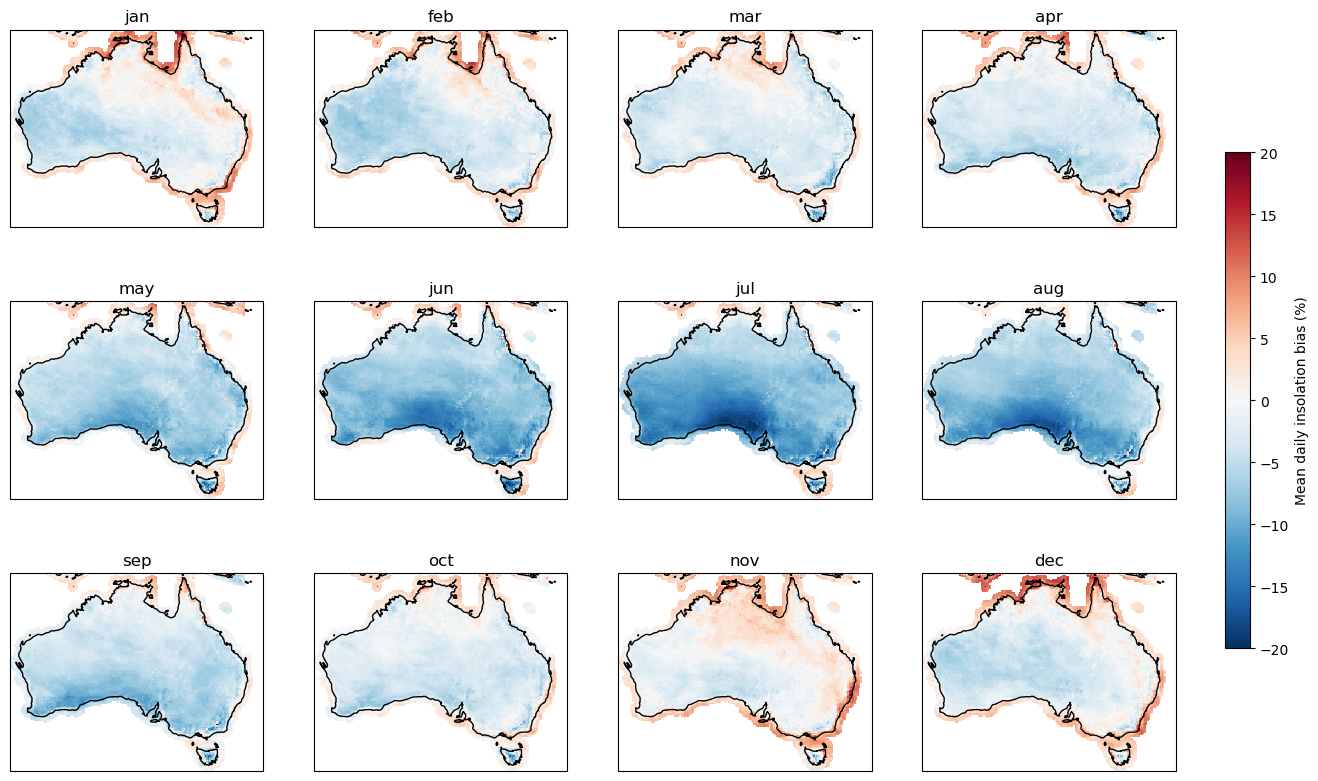

In [9]:
fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(16,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.flatten()
for i, month in enumerate(himawari.data_vars):
    him_data = himawari[month]
    era5_data = era5_aus[month]

    # regrid himawari to era5 resolution
    regridder = xe.Regridder(him_data, era5_data, method='bilinear')
    him_on_era5_grid = regridder(him_data)
    diff_proportional = 100 * (era5_data - him_on_era5_grid) / him_on_era5_grid
    
    mesh = ax[i].pcolormesh(
        diff_proportional['longitude'].values,
        diff_proportional['latitude'].values,
        diff_proportional.values,
        cmap='RdBu_r', shading='auto',
        vmin=-20, vmax=20,
        transform=ccrs.PlateCarree()
    )
    ax[i].coastlines()
    ax[i].set_title(month)
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Mean daily insolation bias (%)")

In [10]:
fig.savefig('/home/548/cd3022/figures/era5-himawari.png')